In [1]:
import numpy as np
import os
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

In [2]:
im_or = cv2.imread("PirabasB_2 - Copy.tif")

In [3]:
im_or.shape


(768, 1024, 3)

In [4]:
im_or.min(), im_or.max()

(0, 255)

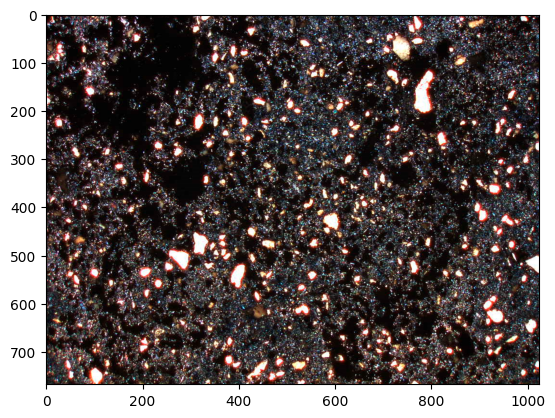

In [5]:
plt.imshow(im_or)

In [6]:
import cv2
# Convert the image to grayscale
grayscale_image = cv2.cvtColor(im_or, cv2.COLOR_BGR2GRAY)

In [7]:
grayscale_image.shape

(768, 1024)

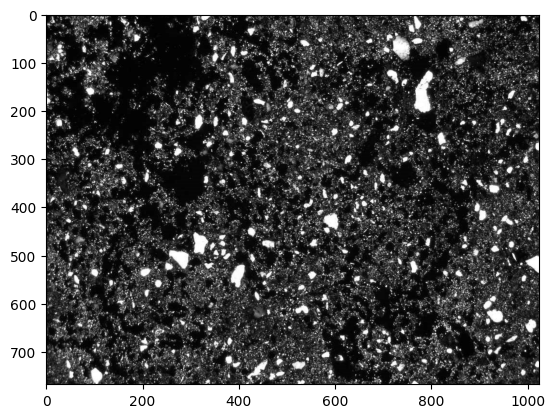

In [8]:
plt.imshow(grayscale_image, cmap="gray")

In [9]:
# Let's see the data as each vector (features) to a regression model
x_weidth, y_height = grayscale_image.shape
grayscale_image.shape, x_weidth, y_height

((768, 1024), 768, 1024)

In [10]:
range(0,x_weidth), range(0, y_height)

(range(0, 768), range(0, 1024))

In [11]:
# Generate the model
# Save each characteristic of the image as features (the pixel value, axis x and y);
pixels_values = [];
axis_x_vector = [];
axis_y_vector = [];

for ii in range(0,x_weidth):
  for jj in range(0,y_height):
    pixel_value_temp = grayscale_image[ii,jj]
    ii_temp = ii
    jj_temp = jj
    pixels_values.append(pixel_value_temp)
    axis_x_vector.append(ii_temp)
    axis_y_vector.append(jj_temp)

In [11]:
len(pixels_values), len(axis_x_vector), len(axis_y_vector)

(786432, 786432, 786432)

In [12]:
import random
Random_values= random.randint(0,len(pixels_values))
Random_values

237986

In [13]:
print("The index", Random_values)
#Checkinf the values and the spatial variation
pixels_values[Random_values] == grayscale_image[axis_x_vector[Random_values],axis_y_vector[Random_values]]

The index 237986


True

In [14]:
#Convert to a numpy array
pixels_values =np.array(pixels_values)
axis_x_vector = np.array(axis_x_vector)
axis_y_vector = np.array(axis_y_vector)

In [15]:
#check the range of the values
pixels_values.min(), pixels_values.max()

(0, 255)

In [16]:
#Let's normalize the data
pixels_values_normalize = (pixels_values - pixels_values.min())/(pixels_values.max() - pixels_values.min())

In [17]:
pixels_values_normalize.min(), pixels_values_normalize.max()

(0.0, 1.0)

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Prepare the input features by stacking the axis vectors and reshaping for CNN
X = np.column_stack((axis_x_vector, axis_y_vector)).reshape(-1, 2, 1)
y = pixels_values_normalize
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create the CNN model
model = Sequential([
    Conv1D(64, kernel_size=2, activation='relu', input_shape=(2, 1)),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer=Adam(), loss='mean_squared_error')

In [56]:
# In that case the X will be pars of axis_x_vector and axis_y_vector
# for instance: [axis_x_vector[0], axis_y_vector[0],..., axis_x_vector[n], axis_y_vector[n] ]
X.shape

(786432, 2, 1)

In [19]:
# Train the model
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
17204/17204 [==============================] - 42s 2ms/step - loss: 4.5530
Epoch 2/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0953
Epoch 3/10
17204/17204 [==============================] - 42s 2ms/step - loss: 0.0605
Epoch 4/10
17204/17204 [==============================] - 42s 2ms/step - loss: 0.0527
Epoch 5/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 6/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 7/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 8/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 9/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 10/10
7373/7373 [==============================] - 6s 818us/step
Mean Squared Error: 0.0524507139025643
Predicted values: [0.20665552 0.20665552 0.20665552 ... 0.20665552 0.20665552 0.20665552]
Actual values: [0.05098039

In [55]:
X_test.shape

(235930, 2, 1)

In [20]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Display predictions
print(f'Predicted values: {y_pred.flatten()}')
print(f'Actual values: {y_test}')

7373/7373 [==============================] - 6s 778us/step
Mean Squared Error: 0.0524507139025643
Predicted values: [0.20665552 0.20665552 0.20665552 ... 0.20665552 0.20665552 0.20665552]
Actual values: [0.05098039 0.84313725 0.16470588 ... 0.20392157 0.00784314 0.16470588]


In [23]:
len(y_pred), len(X_test)

(235930, 235930)

## Predict the original image with the model

In [26]:
im_or.shape, grayscale_image.shape

((768, 1024, 3), (768, 1024))

In [27]:
grayscale_image.min(), grayscale_image.max()

(0, 255)

In [28]:
# Normalize the data
grayscale_image_normalized = (grayscale_image - grayscale_image.min())/(grayscale_image.max() - grayscale_image.min())

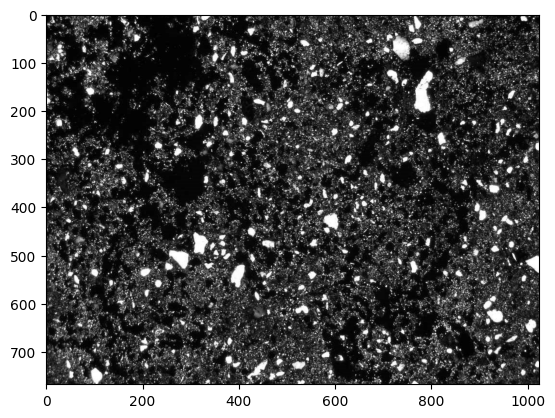

In [29]:
plt.imshow(grayscale_image_normalized, cmap = "gray")

In [30]:
## Let's use the model to reconstruct the image
# Prepare the input features by stacking the axis vectors and reshaping for CNN
X_feature_to_predicit = np.column_stack((axis_x_vector, axis_y_vector)).reshape(-1, 2, 1)

In [31]:
# Make predictions
y_pred_values = model.predict(X_feature_to_predicit)


24576/24576 [==============================] - 23s 934us/step


In [32]:
import numpy as np

# Initialize an empty image array with the same dimensions as the original image
reconstructed_image = np.zeros((x_weidth, y_height), dtype=np.uint8)

# Iterate through the vectors and place each pixel value back into its position
for k in range(len(y_pred_values)):
    ii = axis_x_vector[k]
    jj = axis_y_vector[k]
    reconstructed_image[ii, jj] = pixels_values[k]

# The reconstructed_image now holds the original image


In [33]:
reconstructed_image.shape

(768, 1024)

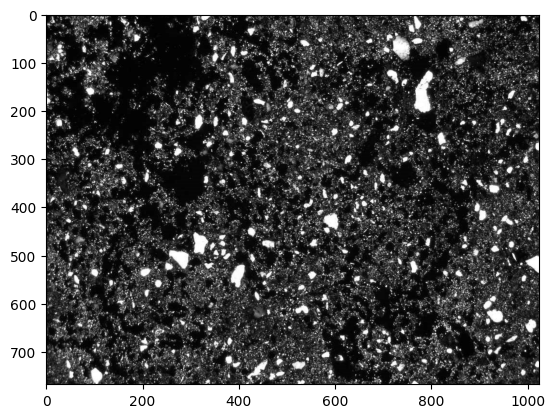

In [34]:
plt.imshow(reconstructed_image, cmap="gray")

In [38]:
grayscale_image.min(), grayscale_image.max(), reconstructed_image.min(), reconstructed_image.max()

(0, 255, 0, 255)

In [39]:
grayscale_image == reconstructed_image

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [46]:
c_false = 0
c_true = 0
for ii in range(0,x_weidth):
  for jj in range(0,y_height):
    temp_bool = grayscale_image[ii,jj] == reconstructed_image[ii,jj]
    if temp_bool == False:
        c_false = c_false + 1
    elif temp_bool == True:
        c_true = c_true + 1
        


In [49]:
c_true == len(axis_x_vector), c_false, c_true, len(axis_x_vector)

(True, 0, 786432, 786432)

In [51]:
# Function to reconstruct the original image and mask
import numpy as np

def jaccard_similarity(image, image_2):
    # Flatten the images to 1D arrays
    image_flat = image.flatten()
    image_2_flat = image_2.flatten()

    # Calculate intersection (number of matching pixels)
    intersection = np.sum(np.logical_and(image_flat, image_2_flat))

    # Calculate union (number of pixels marked as foreground in either image or mask)
    union = np.sum(np.logical_or(image_flat, image_2_flat))

    # Calculate Jaccard similarity coefficient
    jaccard = intersection / union

    return jaccard

In [54]:
jaccard_metric_or_rec = jaccard_similarity(grayscale_image, reconstructed_image)
print("The jaccard similarity between the original image and the reconstruct image is:", jaccard_metric_or_rec)

The jaccard similarity between the original image and the reconstruct image is: 1.0


## Apply the Difusion process: With Deep Learning

## Preprocessing of the data

In [278]:
import numpy as np
import os
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

In [279]:
im_or = cv2.imread("PirabasB_2 - Copy.tif")

In [280]:
im_or.shape


(768, 1024, 3)

In [281]:
im_or.min(), im_or.max()

(0, 255)

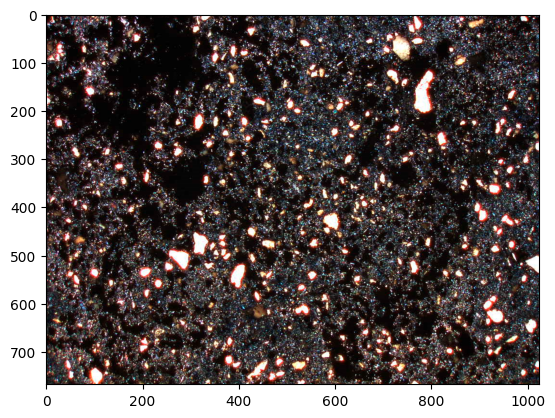

In [282]:
plt.imshow(im_or)

In [283]:
import cv2
# Convert the image to grayscale
grayscale_image = cv2.cvtColor(im_or, cv2.COLOR_BGR2GRAY)

In [284]:
grayscale_image.shape

(768, 1024)

In [285]:
grayscale_image.min(), grayscale_image.max()

(0, 255)

In [405]:
norm_true = 0
if norm_true == 1:
    grayscale_image = (grayscale_image - grayscale_image.min())/ (grayscale_image.max() - grayscale_image.min())
    print("The data was normalized")
else:
    print("The data was not normalized")    

The data was not normalized


In [406]:
grayscale_image.min(), grayscale_image.max()

(0.0, 1.0)

In [407]:
import numpy as np

def forward_process(image, timesteps, beta, norm_true):
    noisy_images = []
    for t in range(timesteps):
        noise = np.random.normal(0, beta, image.shape)
        image = image + noise
        if norm_true == 1:
            image = (image - image.min())/ (image.max() - image.min())
            #print("The data was normalized")
        else:
            False
            #print("The data was not normalized") 
        
        
        noisy_images.append(image)
    return noisy_images

def reverse_process(noisy_images, model):
    for t in reversed(range(len(noisy_images))):
        noisy_image = noisy_images[t]
        noise_estimate = model.predict(noisy_image)  # Modelo treinado para prever o ruído
        noisy_image = noisy_image - noise_estimate
    return noisy_image

In [408]:
import numpy as np

def samples_generate_clean_process(image, timesteps, beta):
    clean_images = []
    for t in range(timesteps):
        clean_images.append(image)
    return clean_images


In [434]:
# Process de difusão progressiva
# Exemplo de uso
timesteps = 75 # We have the 200 samples
timesteps_clean = 2* timesteps
beta = 0.10

noisy_images = forward_process(grayscale_image, timesteps, beta, norm_true)
clean_images = samples_generate_clean_process(grayscale_image, timesteps_clean, beta)

In [435]:
len(noisy_images)

75

In [436]:
noisy_images = np.array(noisy_images)
clean_images = np.array(clean_images)
noisy_images.shape, clean_images.shape

((75, 768, 1024), (150, 768, 1024))

In [437]:
## Check the range values to normalize the data
clean_images.min(), clean_images.max(), noisy_images.min() , noisy_images.max()

(0.0, 1.0, -4.19275663059671, 5.387075982908863)

In [438]:
len(clean_images)

150

94


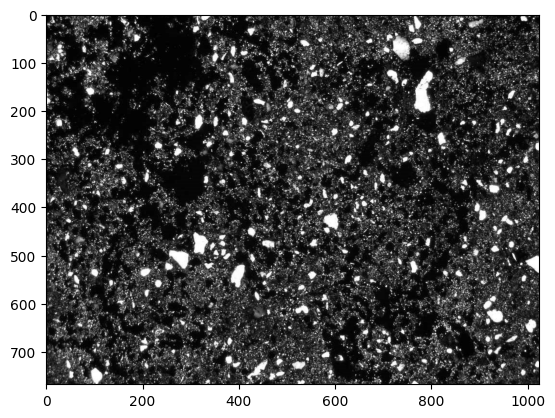

In [439]:
import random 
idx_show_samples = random.randint(0,len(clean_images)) # without range incluse the max values 
print(idx_show_samples)
plt.imshow(clean_images[idx_show_samples, :, :], cmap="gray")

21


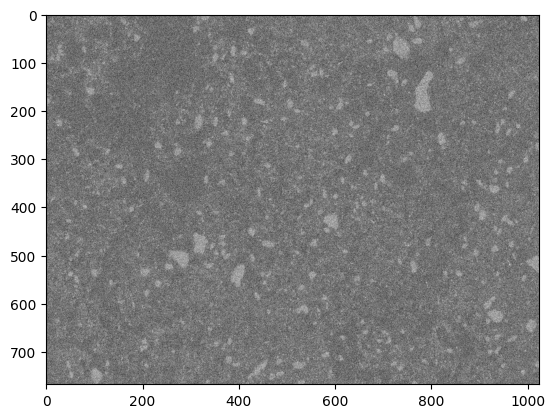

In [440]:
import random 
idx_show_samples = random.randint(0,len(noisy_images)) # without range incluse the max values 
print(idx_show_samples)
plt.imshow(noisy_images[idx_show_samples, :, :], cmap="gray")

In [441]:
## Check the range values to normalize the data
clean_images.min(), clean_images.max(), noisy_images.min() , noisy_images.max()

(0.0, 1.0, -4.19275663059671, 5.387075982908863)

In [442]:
# Concatenate along the first axis (axis=0)
combined_images = np.concatenate([clean_images, noisy_images], axis=0)
combined_images.shape

(225, 768, 1024)

In [443]:
import numpy as np

# Assuming noisy_images is your tensor of shape (200, 768, 1024)
shuffled_indices = np.random.permutation(combined_images.shape[0])
combined_images_shuffled = combined_images[shuffled_indices]
# Now noisy_images_shuffled contains the noisy images shuffled along the first axis (samples)


In [444]:
combined_images_shuffled.shape

(225, 768, 1024)

144
The max and min value of the noisy image 0.0 1.0


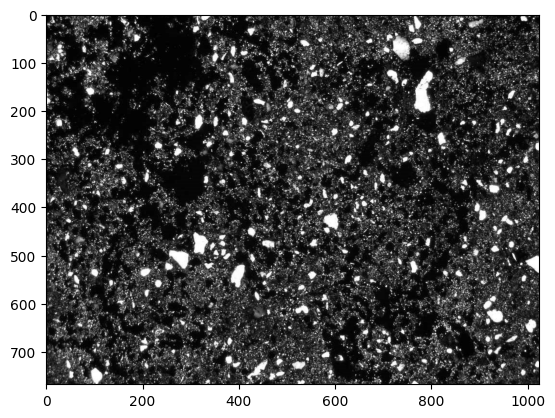

In [445]:
import random
index_combined_images_shuffled = random.randint(0,len(combined_images_shuffled)-1)
print(index_combined_images_shuffled)
plt.imshow(combined_images_shuffled[index_combined_images_shuffled,:, :], cmap="gray")
print("The max and min value of the noisy image", combined_images_shuffled[index_combined_images_shuffled,:, :].min(), combined_images_shuffled[index_combined_images_shuffled,:, :].max())

In [446]:
## Pressão, velocidade and modulo elástico.
## Try to introduce this information in the model

## Deep Convolutional GAN (DCGAN). 

In [203]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, BatchNormalization, Flatten, Dense
from tensorflow.keras.models import Sequential

# Constants
#BATCH_SIZE = 2  # Adjust batch size as needed
IMAGE_SHAPE = (768, 1024, 1)  # Assuming grayscale images

def build_generator():
    model = Sequential()

    # Encoder
    model.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu', input_shape=IMAGE_SHAPE))
    model.add(BatchNormalization())
    model.add(Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(BatchNormalization())
    
    # Decoder
    model.add(Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2DTranspose(32, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(1, kernel_size=3, strides=1, padding='same', activation='sigmoid'))

    return model


In [204]:
def build_discriminator():
    model = Sequential()

    # Convolutional layers
    model.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu', input_shape=IMAGE_SHAPE))
    model.add(Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(Conv2D(128, kernel_size=3, strides=2, padding='same', activation='relu'))

    # Flatten and classify
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model


In [205]:
generator = build_generator()
generator.compile(optimizer='adam', loss='mse')

discriminator = build_discriminator()
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#discriminator.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

In [206]:
discriminator.trainable = False  # Freeze the discriminator during GAN training

gan_input = tf.keras.Input(shape=IMAGE_SHAPE)
generated_image = generator(gan_input)
gan_output = discriminator(generated_image)

gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')
#gan.compile(optimizer='adam', loss='mse')

In [207]:
import numpy as np

# Assuming noisy_images is already loaded and has shape (300, 768, 1024)
combined_images_shuffled = np.expand_dims(combined_images_shuffled, axis=-1)  # Add channel dimension

In [208]:
combined_images_shuffled.shape

(200, 768, 1024, 1)

In [209]:
# num_batches = 16  # Adjust batch size as needed
# IMAGE_SHAPE = (768, 1024, 1)  # Assuming grayscale images
# num_epochs = 10

In [210]:
# # Assuming noisy_images is your input data tensor
# # Reshape noisy_images to (300, 768, 1024, 1) if necessary
# # Train the GAN iteratively
# for epoch in range(num_epochs):
#     for batch in range(num_batches):
#         # Train discriminator on real data
#         real_images = noisy_images[batch * BATCH_SIZE : (batch + 1) * BATCH_SIZE]
#         real_labels = np.ones((BATCH_SIZE, 1))  # Labels for real images
        
#         discriminator_loss_real = discriminator.train_on_batch(real_images, real_labels)
        
#         # Train discriminator on generated (fake) data
#         noise = np.random.normal(0, 1, (BATCH_SIZE, *IMAGE_SHAPE))
#         generated_images = generator.predict(noise)
#         fake_labels = np.zeros((BATCH_SIZE, 1))  # Labels for fake images
        
#         discriminator_loss_fake = discriminator.train_on_batch(generated_images, fake_labels)
        
#         # Train generator (full GAN)
#         noise = np.random.normal(0, 1, (BATCH_SIZE, *IMAGE_SHAPE))
#         gan_labels = np.ones((BATCH_SIZE, 1))  # Labels for generated images (trick discriminator)
        
#         gan_loss = gan.train_on_batch(noise, gan_labels)
        
#         # Print progress
#         print(f"Epoch {epoch + 1}/{num_epochs}, Batch {batch}/{num_batches}, "
#               f"Discriminator Loss: {discriminator_loss_real[0] + discriminator_loss_fake[0]}, "
#               f"GAN Loss: {gan_loss}")


In [211]:
BATCH_SIZE = 1
num_batches = 8  # Adjust batch size as needed
IMAGE_SHAPE = (768, 1024, 1)  # Assuming grayscale images
num_epochs = 30

In [212]:
combined_images_shuffled.shape, combined_images_shuffled.dtype

((200, 768, 1024, 1), dtype('float64'))

In [213]:
combined_images_shuffled = combined_images_shuffled.astype("float16")

In [214]:
combined_images_shuffled.max(), combined_images_shuffled.min()

(870.0, -651.5)

In [215]:
combined_images_shuffled.max(), combined_images_shuffled.min()

(870.0, -651.5)

In [216]:
# To fix the error above:

# Assuming noisy_images is your input data tensor
# Reshape noisy_images to (300, 768, 1024, 1) if necessary
# Train the GAN iteratively
#with tf.device('/GPU:0'):
with tf.device('/CPU:0'):    
    for epoch in range(num_epochs):
        for batch in range(num_batches):
            # Train discriminator on real data
            real_images = combined_images_shuffled[batch * BATCH_SIZE : (batch + 1) * BATCH_SIZE]
            real_labels = np.ones((BATCH_SIZE, 1))  # Labels for real images
        
            discriminator_loss_real = discriminator.train_on_batch(real_images, real_labels)
        
            # Train discriminator on generated (fake) data
            noise = np.random.normal(0, 1, (BATCH_SIZE, *IMAGE_SHAPE))
            generated_images = generator.predict(noise)
            fake_labels = np.zeros((BATCH_SIZE, 1))  # Labels for fake images
        
            discriminator_loss_fake = discriminator.train_on_batch(generated_images, fake_labels)
        
            # Train generator (full GAN)
            noise = np.random.normal(0, 1, (BATCH_SIZE, *IMAGE_SHAPE))
            gan_labels = np.ones((BATCH_SIZE, 1))  # Labels for generated images (trick discriminator)
        
            gan_loss = gan.train_on_batch(noise, gan_labels)
        
            # Print progress
            print(f"Epoch {epoch + 1}/{num_epochs}, Batch {batch}/{num_batches}, "
                  f"Discriminator Loss: {discriminator_loss_real[0] + discriminator_loss_fake[0]}, "
                  f"GAN Loss: {gan_loss}")

1/1 [==============================] - 0s 240ms/step
Epoch 1/30, Batch 0/8, Discriminator Loss: 24.550604820251465, GAN Loss: 3.1039865122650667e-10
1/1 [==============================] - 0s 181ms/step
Epoch 1/30, Batch 1/8, Discriminator Loss: 16.745820999145508, GAN Loss: 1.1660693743920092e-08
1/1 [==============================] - 0s 171ms/step
Epoch 1/30, Batch 2/8, Discriminator Loss: 7.741457939147949, GAN Loss: 0.00010080623178509995
1/1 [==============================] - 0s 175ms/step
Epoch 1/30, Batch 3/8, Discriminator Loss: 0.1872715801000595, GAN Loss: 0.14799709618091583
1/1 [==============================] - 0s 171ms/step
Epoch 1/30, Batch 4/8, Discriminator Loss: 0.0011816737242043018, GAN Loss: 3.3166306018829346
1/1 [==============================] - 0s 174ms/step
Epoch 1/30, Batch 5/8, Discriminator Loss: 4.2009698518086225e-05, GAN Loss: 6.62616491317749
1/1 [==============================] - 0s 169ms/step
Epoch 1/30, Batch 6/8, Discriminator Loss: 3.324875706312014

In [234]:
# After training, use the generator to denoise images
# Example code to denoise a single image:
def denoise_image(image):
    # Assuming 'image' is your input noisy image of shape (768, 1024, 1)
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    denoised_image = generator.predict(image)
    return denoised_image[0]

In [235]:
import numpy as np

# Assuming noisy_images is already loaded and has shape (300, 768, 1024)
noisy_images_to_predict = np.expand_dims(noisy_images, axis=-1)  # Add channel dimension

In [236]:
noisy_images.shape, noisy_images_to_predict.shape

((100, 768, 1024), (100, 768, 1024, 1))

In [237]:
noisy_images_to_predict.max(), noisy_images_to_predict.min()

(869.840169751827, -651.5579441653415)

The sample number 90
1/1 [==============================] - 0s 18ms/step


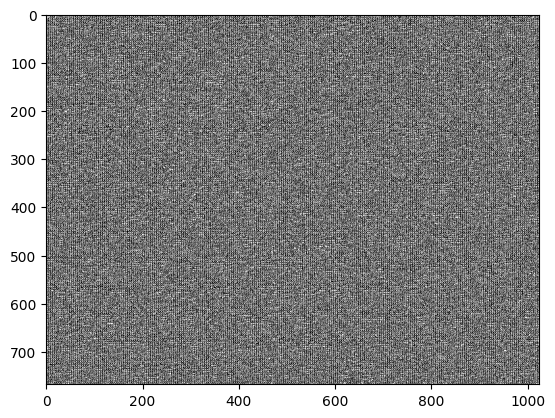

In [240]:
import random 

index_pred = random.randint(0, len(noisy_images_to_predict)- 1)
# Example usage:

print("The sample number", index_pred)
image_to_predict = noisy_images_to_predict[index_pred]  # Example noisy image
denoised_image_predict = denoise_image(image_to_predict)

plt.imshow(denoised_image_predict, cmap="gray")

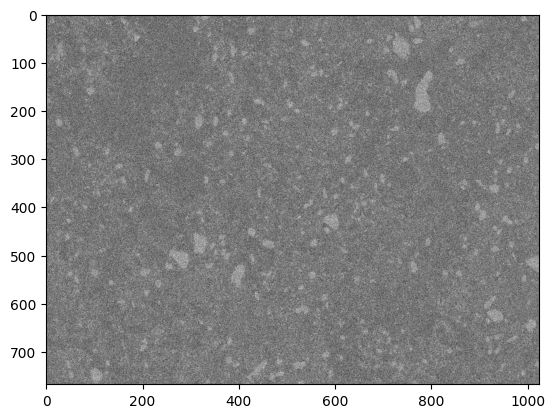

In [241]:
plt.imshow(image_to_predict, cmap="gray")

In [223]:
denoised_image_predict.shape, denoised_image_predict.max(), denoised_image_predict.min()

((768, 1024, 1), 1.0, 0.0)

## cGAN or pix2pix

In [447]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, BatchNormalization, ReLU, Concatenate
from tensorflow.keras.models import Model

def build_generator(input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    
    # Encoder
    e1 = Conv2D(64, kernel_size=4, strides=2, padding='same')(inputs)
    e2 = ReLU()(e1)
    e3 = BatchNormalization()(e2)
    e4 = Conv2D(128, kernel_size=4, strides=2, padding='same')(e3)
    
    # Decoder
    d1 = ReLU()(e4)
    d2 = BatchNormalization()(d1)
    d3 = Conv2DTranspose(64, kernel_size=4, strides=2, padding='same')(d2)
    d4 = Concatenate()([d3, e2])
    d5 = Conv2DTranspose(1, kernel_size=4, strides=2, padding='same', activation='tanh')(d4)
    
    return Model(inputs, d5)

input_shape = (768, 1024, 1)
generator = build_generator(input_shape)

In [448]:
from tensorflow.keras.layers import Input, Concatenate, LeakyReLU, Dropout, Flatten, Dense

def build_discriminator(input_shape):
    noisy_image = Input(shape=input_shape)
    clean_image = Input(shape=input_shape)
    
    combined_images = Concatenate()([noisy_image, clean_image])
    
    d = Conv2D(64, kernel_size=4, strides=2, padding='same')(combined_images)
    d = LeakyReLU(alpha=0.2)(d)
    d = Dropout(0.5)(d)
    d = Conv2D(128, kernel_size=4, strides=2, padding='same')(d)
    d = LeakyReLU(alpha=0.2)(d)
    d = Dropout(0.5)(d)
    d = Flatten()(d)
    d = Dense(1, activation='sigmoid')(d)
    
    return Model([noisy_image, clean_image], d)

discriminator = build_discriminator(input_shape)
discriminator.compile(optimizer='adam', loss='binary_crossentropy')


In [449]:
# Freeze the discriminator when training the generator
discriminator.trainable = False

noisy_input = Input(shape=input_shape)
generated_image = generator(noisy_input)
validity = discriminator([noisy_input, generated_image])

gan = Model(noisy_input, validity)
gan.compile(optimizer='adam', loss=['binary_crossentropy', 'mae'], loss_weights=[1, 100])


In [450]:
import numpy as np

def train_gan(generator, discriminator, gan, noisy_images, clean_images, epochs, batch_size):
    for epoch in range(epochs):
        for batch in range(int(noisy_images.shape[0] / batch_size)):
            # Select a random batch of images
            idx = np.random.randint(0, noisy_images.shape[0], batch_size)
            noisy_batch = noisy_images[idx]
            clean_batch = clean_images[idx]
            
            # Generate fake clean images
            generated_images = generator.predict(noisy_batch)
            
            # Train the discriminator
            d_loss_real = discriminator.train_on_batch([noisy_batch, clean_batch], np.ones((batch_size, 1)))
            d_loss_fake = discriminator.train_on_batch([noisy_batch, generated_images], np.zeros((batch_size, 1)))
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
            
            # Train the generator
            g_loss = gan.train_on_batch(noisy_batch, [np.ones((batch_size, 1)), clean_batch])
            
            # Print the progress
            d_loss_value = d_loss if isinstance(d_loss, float) else d_loss[0]
            g_loss_value = g_loss if isinstance(g_loss, float) else g_loss[0]
            print(f"{epoch} [D loss: {d_loss_value}] [G loss: {g_loss_value}]")

# Example usage:
# Assuming noisy_images and clean_images are numpy arrays of shape (100, 768, 1024, 1)
train_gan(generator, discriminator, gan, noisy_images, clean_images, epochs=10, batch_size=16)

1/1 [==============================] - 0s 103ms/step
0 [D loss: 86.17030563950539] [G loss: 1.7989947097112047e-13]
1/1 [==============================] - 0s 33ms/step
0 [D loss: 5.589176177978516] [G loss: 60.6906623840332]
1/1 [==============================] - 0s 33ms/step
0 [D loss: 11.517147064208984] [G loss: 43.261234283447266]
1/1 [==============================] - 0s 31ms/step
0 [D loss: 0.2629401981859591] [G loss: 0.009992542676627636]
1/1 [==============================] - 0s 31ms/step
1 [D loss: 5.509142875671387] [G loss: 1.7113458428141826e-09]
1/1 [==============================] - 0s 31ms/step
1 [D loss: 7.299628013157644e-09] [G loss: 2.5948004722595215]
1/1 [==============================] - 0s 31ms/step
1 [D loss: 1.1777283340984891e-10] [G loss: 25.374011993408203]
1/1 [==============================] - 0s 30ms/step
1 [D loss: 0.00042579657043103486] [G loss: 10.643411636352539]
1/1 [==============================] - 0s 31ms/step
2 [D loss: 3.6744195925463146] [G l

The sample number 45
1/1 [==============================] - 0s 18ms/step


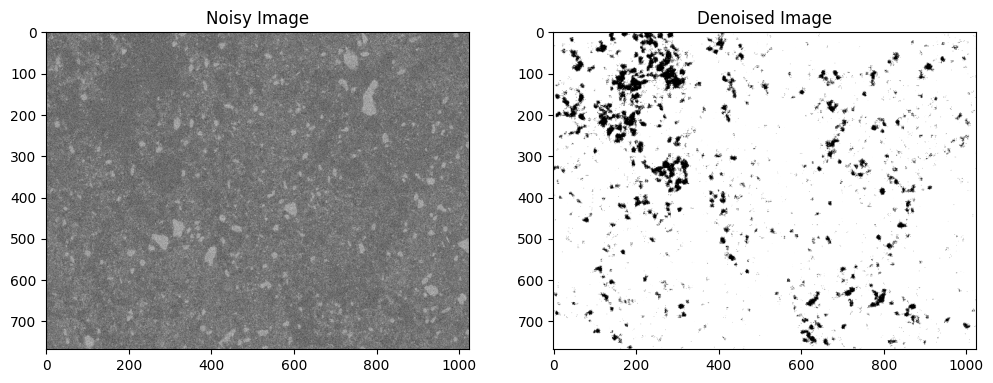

In [461]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Assuming your generator is trained and noisy_images_to_predict is the tensor of noisy images

# Function to denoise an image using the trained generator
def denoise_image(generator, image):
    # Add batch dimension and predict
    image = np.expand_dims(image, axis=0)  # Shape (1, 768, 1024, 1)
    denoised_image = generator.predict(image)
    # Remove batch dimension
    denoised_image = np.squeeze(denoised_image, axis=0)  # Shape (768, 1024, 1)
    return denoised_image

# Example usage
index_pred = random.randint(0, len(noisy_images_to_predict) - 1)
print("The sample number", index_pred)
image_to_predict = noisy_images_to_predict[index_pred]  # Example noisy image
denoised_image_predict = denoise_image(generator, image_to_predict)

# Plot the original noisy image and the denoised image
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Noisy Image")
plt.imshow(image_to_predict.squeeze(), cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Denoised Image")
plt.imshow(denoised_image_predict.squeeze(), cmap="gray")

plt.show()